# Olivia Weihmuller
<h1 align="center">TS4: Primeras nociones de estimación espectral.</h1>

En este trabajo práctico se analiza el desempeño de distintos estimadores espectrales de amplitud y frecuencia aplicados a una senoidal desintonizada y contaminada con ruido aditivo.

El experimento consta de 200 realizaciones (r = 1, ..., 200) de N = 1000 muestras cada una. Para que el código sea más rápido y evitar bucles `for`, las señales se guardaron en una matriz de 1000 filas por 200 columnas. De esta forma, cada columna es un experimento de 1000 muestras y se procesan las 200 realizaciones al mismo tiempo.

Para simular un escenario de medición realista, la frecuencia digital de la señal se modela como una variable aleatoria con distribución uniforme fr \~ U(-2, 2) bins alrededor de la frecuencia nominal Ω0 = N/4. Esta desintonía aleatoria refleja el hecho de que, en aplicaciones reales, la frecuencia analógica de interés rara vez coincide de forma exacta con un bin entero de la grilla discreta de la DFT (Δf = 2π/N).

Adicionalmente, a la matriz de señal se le suma una matriz de ruido blanco Gaussiano incorrelado na(n) \~ N(0, σ²) de media cero, parametrizado para niveles de SNR de 3 dB y 10 dB (asumiendo una potencia de señal normalizada Ps = 1 W).

El truncamiento temporal a N = 1000 muestras equivale a multiplicar la señal continua por una ventana rectangular, lo que introduce desparramo espectral (spectral leakage) y pérdida por acanalado (scalloping loss) cuando la frecuencia no cae en un bin exacto. El objetivo de este TP es comparar la respuesta de cuatro ventanas espectrales (Rectangular, Flat-top, Blackman-Harris y Hann) aplicadas matricialmente y previamente normalizadas por su ganancia coherente ($\sum w[n]$). Para ello, se evalúa cuantitativamente el compromiso entre sesgo y varianza en la estimación de amplitud ($\hat{a}_1 = \max|X|$) y bin de frecuencia ($\hat{k}_1 = \arg\max|X|$) a partir del promedio estadístico sobre las 200 realizaciones.

In [15]:
"""
Created on Wed Sep  9 19:24:56 2026
@author: oliviaweihmuller

TP: Estimadores de Amplitud (a1) y Frecuencia (Omega1) con distintas ventanas
Para SNR = 3 dB y SNR = 10 dB (Todas las ventanas, tablas e histogramas completos)
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

rng = np.random.default_rng(42)

fs = 1000          # Hz
N = 1000           # cantidad de muestras
Ps = 1             # W, potencia deseada de la senoidal
a0 = np.sqrt(2*Ps) # amplitud calibrada para potencia unitaria (1.4142 V)

om0 = N/4          # bin central:  N/4 = 250
bin0 = int(om0)    # se lo paso a entero por di tenia coma por la division

r = 200            # cantidad de realizaciones

#%%
fr = rng.uniform(-2, 2, r)
frec_real = om0 + fr                # Frecuencia real en bins (248 a 252)
om1_rad = (2*np.pi/N) * frec_real

n = np.arange(N)
nfil = n.reshape((N, 1))
om1_col = om1_rad.reshape((1, r))

sen = a0 * np.sin(om1_col * nfil)   # (N, r)

In [16]:
#%% 
#                        VENTANAS

ventana_rect = np.ones(N).reshape((N, 1))   # rectangular = sin ventana

ventana_ft = signal.windows.flattop(N)
ventana_ft = (ventana_ft / (np.sum(ventana_ft)/N)).reshape((N, 1))

ventana_bh = signal.windows.blackmanharris(N)
ventana_bh = (ventana_bh / (np.sum(ventana_bh)/N)).reshape((N, 1))

ventana_h = signal.windows.hann(N)
ventana_h = (ventana_h / (np.sum(ventana_h)/N)).reshape((N, 1))


Al aplicar ventanas espectrales no rectangulares (como Hann, Blackman-Harris o Flat-top), las muestras cercanas a los extremos del bloque temporal se atenuan gradualmente hasta valer cero con el fin de suavizar las discontinuidades y reducir el desparramo espectral. Esta atenuación provoca una pérdida de energía y amplitud en la señal resultando en un espectro atenuado. Por este motivo, es necesario normalizar cada ventana.

In [17]:
#%% 
#                         SNR 3 dB

SNR_db3 = 3
desv3 = np.sqrt(10**(-SNR_db3/10))
na3 = rng.normal(0, desv3, (N, r))
senal_final3 = sen + na3

# FFT para cada ventana
fft_v3  = (1/N) * np.fft.fft(senal_final3 * ventana_rect, axis=0)
fft_ft3 = (1/N) * np.fft.fft(senal_final3 * ventana_ft, axis=0)
fft_bh3 = (1/N) * np.fft.fft(senal_final3 * ventana_bh, axis=0)
fft_h3  = (1/N) * np.fft.fft(senal_final3 * ventana_h, axis=0)

# ESTIMADOR DE AMPLITUD (evaluado en bin0 = 250)
a1_v3  = 2 * np.abs(fft_v3[bin0, :])
a1_ft3 = 2 * np.abs(fft_ft3[bin0, :])
a1_bh3 = 2 * np.abs(fft_bh3[bin0, :])
a1_h3  = 2 * np.abs(fft_h3[bin0, :])

# ESTIMADOR DE FRECUENCIA (bin pico en el espectro positivo 0 a N//2)
est_frec_v3  = np.argmax(np.abs(fft_v3[:N//2, :]), axis=0)
est_frec_ft3 = np.argmax(np.abs(fft_ft3[:N//2, :]), axis=0)
est_frec_bh3 = np.argmax(np.abs(fft_bh3[:N//2, :]), axis=0)
est_frec_h3  = np.argmax(np.abs(fft_h3[:N//2, :]), axis=0)

# Errores de Frecuencia SNR = 3 dB
err_frec_v3  = est_frec_v3 - frec_real
err_frec_ft3 = est_frec_ft3 - frec_real
err_frec_bh3 = est_frec_bh3 - frec_real
err_frec_h3  = est_frec_h3 - frec_real

#%%                  
#                        SNR 10 db

SNR_db10 = 10
desv10 = np.sqrt(10**(-SNR_db10/10))
na10 = rng.normal(0, desv10, (N, r))
senal_final10 = sen + na10

# FFT para cada ventana
fft_v10  = (1/N) * np.fft.fft(senal_final10 * ventana_rect, axis=0)
fft_ft10 = (1/N) * np.fft.fft(senal_final10 * ventana_ft, axis=0)
fft_bh10 = (1/N) * np.fft.fft(senal_final10 * ventana_bh, axis=0)
fft_h10  = (1/N) * np.fft.fft(senal_final10 * ventana_h, axis=0)

# ESTIMADOR DE AMPLITUD (evaluado en bin0 = 250)
a1_v10  = 2 * np.abs(fft_v10[bin0, :])
a1_ft10 = 2 * np.abs(fft_ft10[bin0, :])
a1_bh10 = 2 * np.abs(fft_bh10[bin0, :])
a1_h10  = 2 * np.abs(fft_h10[bin0, :])

# ESTIMADOR DE FRECUENCIA (bin pico en el espectro positivo 0 a N//2)
est_frec_v10  = np.argmax(np.abs(fft_v10[:N//2, :]), axis=0)
est_frec_ft10 = np.argmax(np.abs(fft_ft10[:N//2, :]), axis=0)
est_frec_bh10 = np.argmax(np.abs(fft_bh10[:N//2, :]), axis=0)
est_frec_h10  = np.argmax(np.abs(fft_h10[:N//2, :]), axis=0)

# Errores de Frecuencia SNR = 10 dB
err_frec_v10  = est_frec_v10 - frec_real
err_frec_ft10 = est_frec_ft10 - frec_real
err_frec_bh10 = est_frec_bh10 - frec_real
err_frec_h10  = est_frec_h10 - frec_real

En esta parte del codigo, se calcula la senal multiplicada con la ventana, se le calcula la fft y se calcula los estimadores.

In [18]:
#%%                         TABLAS
print("=" * 75)
print("              TABLAS DE RESULTADOS (SNR = 3 dB)")
print("=" * 75)
print("--- ESTIMACIÓN DE AMPLITUD ---")
print(f"Rectangular      -> sesgo = {np.mean(a1_v3)-a0:+.4f} | varianza = {np.var(a1_v3):.5f}")
print(f"Flat-top         -> sesgo = {np.mean(a1_ft3)-a0:+.4f} | varianza = {np.var(a1_ft3):.5f}")
print(f"Blackman-Harris  -> sesgo = {np.mean(a1_bh3)-a0:+.4f} | varianza = {np.var(a1_bh3):.5f}")
print(f"Hann             -> sesgo = {np.mean(a1_h3)-a0:+.4f} | varianza = {np.var(a1_h3):.5f}")

print("\n--- ESTIMACIÓN DE FRECUENCIA (en bins) ---")
print(f"Rectangular      -> sesgo = {np.mean(err_frec_v3):+.4f} | varianza = {np.var(err_frec_v3):.5f}")
print(f"Flat-top         -> sesgo = {np.mean(err_frec_ft3):+.4f} | varianza = {np.var(err_frec_ft3):.5f}")
print(f"Blackman-Harris  -> sesgo = {np.mean(err_frec_bh3):+.4f} | varianza = {np.var(err_frec_bh3):.5f}")
print(f"Hann             -> sesgo = {np.mean(err_frec_h3):+.4f} | varianza = {np.var(err_frec_h3):.5f}")

print("\n" + "=" * 75)
print("              TABLAS DE RESULTADOS (SNR = 10 dB)")
print("=" * 75)
print("--- ESTIMACIÓN DE AMPLITUD ---")
print(f"Rectangular      -> sesgo = {np.mean(a1_v10)-a0:+.4f} | varianza = {np.var(a1_v10):.5f}")
print(f"Flat-top         -> sesgo = {np.mean(a1_ft10)-a0:+.4f} | varianza = {np.var(a1_ft10):.5f}")
print(f"Blackman-Harris  -> sesgo = {np.mean(a1_bh10)-a0:+.4f} | varianza = {np.var(a1_bh10):.5f}")
print(f"Hann             -> sesgo = {np.mean(a1_h10)-a0:+.4f} | varianza = {np.var(a1_h10):.5f}")

print("\n--- ESTIMACIÓN DE FRECUENCIA (en bins) ---")
print(f"Rectangular      -> sesgo = {np.mean(err_frec_v10):+.4f} | varianza = {np.var(err_frec_v10):.5f}")
print(f"Flat-top         -> sesgo = {np.mean(err_frec_ft10):+.4f} | varianza = {np.var(err_frec_ft10):.5f}")
print(f"Blackman-Harris  -> sesgo = {np.mean(err_frec_bh10):+.4f} | varianza = {np.var(err_frec_bh10):.5f}")
print(f"Hann             -> sesgo = {np.mean(err_frec_h10):+.4f} | varianza = {np.var(err_frec_h10):.5f}")


              TABLAS DE RESULTADOS (SNR = 3 dB)
--- ESTIMACIÓN DE AMPLITUD ---
Rectangular      -> sesgo = -0.8943 | varianza = 0.20683
Flat-top         -> sesgo = -0.1077 | varianza = 0.02087
Blackman-Harris  -> sesgo = -0.4731 | varianza = 0.12471
Hann             -> sesgo = -0.6809 | varianza = 0.21914

--- ESTIMACIÓN DE FRECUENCIA (en bins) ---
Rectangular      -> sesgo = +0.0095 | varianza = 0.08173
Flat-top         -> sesgo = +0.0295 | varianza = 0.17187
Blackman-Harris  -> sesgo = -0.0055 | varianza = 0.08191
Hann             -> sesgo = -0.0005 | varianza = 0.08175

              TABLAS DE RESULTADOS (SNR = 10 dB)
--- ESTIMACIÓN DE AMPLITUD ---
Rectangular      -> sesgo = -0.8945 | varianza = 0.20849
Flat-top         -> sesgo = -0.1094 | varianza = 0.01913
Blackman-Harris  -> sesgo = -0.4738 | varianza = 0.12753
Hann             -> sesgo = -0.6821 | varianza = 0.22403

--- ESTIMACIÓN DE FRECUENCIA (en bins) ---
Rectangular      -> sesgo = +0.0195 | varianza = 0.08113
Flat-top   

Para el estimador de amplitud, en ambos casos se observa que el sesgo entre las distintas ventanas varía en cierta medida, pero la diferencia principal se encuentra en la varianza: la varianza de la ventana Flat-top es un orden de magnitud menor (alrededor de 0.02) en comparación con las demás (que rondan entre 0.12 y 0.22). Esto es una gran ventaja, ya que la varianza mide la dispersión o variabilidad aleatoria de las estimaciones alrededor de su valor medio debido al ruido aditivo y a las fluctuaciones de los datos, lo cual es algo aleatorio e impredecible. Por otro lado, el sesgo mide el error promedio o sistemático del estimador (asociado a la pérdida por acanalado o scalloping loss al no caer la frecuencia en el centro del bin). La diferencia crucial es que el sesgo es un error determinístico y corregible: se puede compensar fácilmente sumando el desvío o multiplicando por el factor de corrección de la ventana. Teniendo en cuenta que el sesgo se puede corregir pero la varianza no, para el estimador de amplitud conviene utilizar la ventana Flat-top debido a su mínima varianza.

Respecto a la SNR, el sesgo en la estimación de amplitud prácticamente no cambia al pasar de 3 dB a 10 dB. Esto pasa porque la caída en la amplitud medida se debe exclusivamente a cómo la ventana suaviza la señal cuando la frecuencia no cae justo en el centro de un bin. Como esa pérdida de altura depende solo de la ventana y de dónde cayó la frecuencia, el nivel de ruido no la altera. El ruido solo hace que las mediciones individuales fluctúen de forma aleatoria, pero al calcular el promedio de todas las realizaciones esas fluctuaciones se cancelan, haciendo que el sesgo promedio sea el mismo a 3 dB y a 10 dB.

Para el estimador de frecuencia discreta, se observa que el sesgo en todas las ventanas es sumamente pequeño. Esto sucede por la simetría de la desintonía aleatoria U(-2, 2) alrededor de la frecuencia nominal, donde los errores a izquierda y derecha se compensan al promediar las 200 realizaciones. Por su parte, la varianza de la frecuencia es mayor para la ventana Flat-top (alrededor de 0.12 a 0.17) en comparación con las otras ventanas (alrededor de 0.08). Esto se debe a que el lóbulo principal de la ventana Flat-top tiene una cima plana y ancha, lo que provoca que las fluctuaciones de ruido desplacen con mayor facilidad la ubicación del bin del valor máximo (argmax).

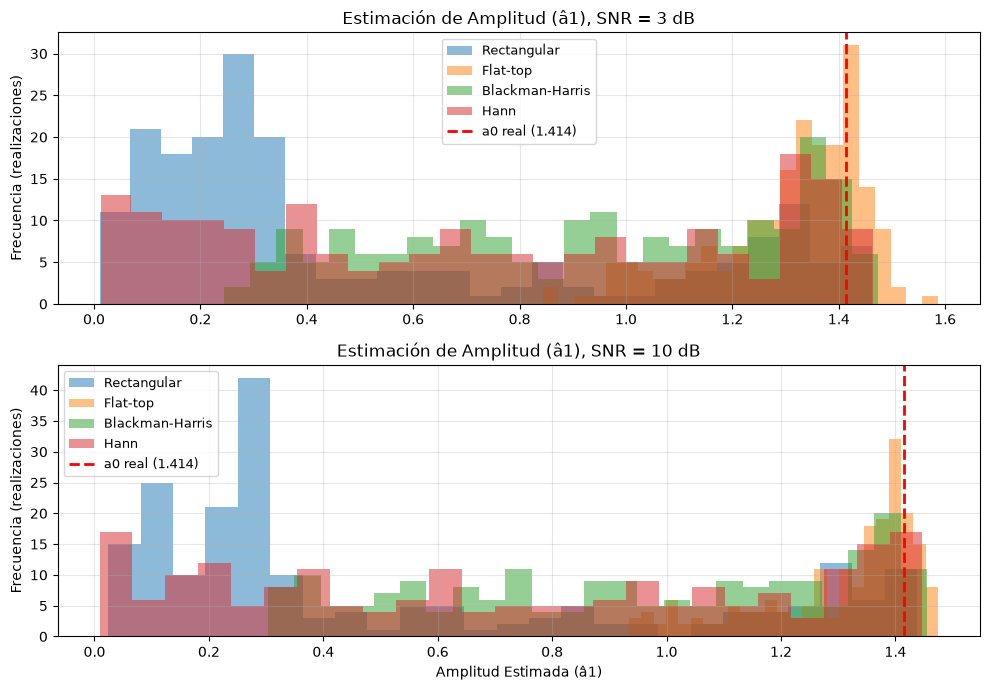

In [19]:
#%%                   HISTOGRAMA DE AMPLITUD

plt.figure(figsize=(10, 7))

plt.subplot(2, 1, 1)
plt.hist(a1_v3, bins=25, alpha=0.5, label='Rectangular')
plt.hist(a1_ft3, bins=25, alpha=0.5, label='Flat-top')
plt.hist(a1_bh3, bins=25, alpha=0.5, label='Blackman-Harris')
plt.hist(a1_h3, bins=25, alpha=0.5, label='Hann')
plt.axvline(a0, color='r', linestyle='--', linewidth=2, label=f'a0 real ({a0:.3f})')
plt.title('Estimación de Amplitud (â1), SNR = 3 dB')
plt.ylabel('Frecuencia (realizaciones)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)

plt.subplot(2, 1, 2)
plt.hist(a1_v10, bins=25, alpha=0.5, label='Rectangular')
plt.hist(a1_ft10, bins=25, alpha=0.5, label='Flat-top')
plt.hist(a1_bh10, bins=25, alpha=0.5, label='Blackman-Harris')
plt.hist(a1_h10, bins=25, alpha=0.5, label='Hann')
plt.axvline(a0, color='r', linestyle='--', linewidth=2, label=f'a0 real ({a0:.3f})')
plt.title('Estimación de Amplitud (â1), SNR = 10 dB')
plt.xlabel('Amplitud Estimada (â1)')
plt.ylabel('Frecuencia (realizaciones)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()


Se graficaron los histogramas para analizar el comportamiento visual de las estimaciones. En las ventanas que presentan varianza alta (como la Rectangular, Hann y Blackman-Harris), se observa una gran dispersión en los gráficos, con valores muy desparramados a lo largo del eje debido a las fluctuaciones aleatorias. En cambio, el histograma de la ventana Flat-top se muestra sumamente estrecho y concentrado en un rango muy acotado, lo que evidencia visualmente su baja varianza y la estabilidad del estimador.

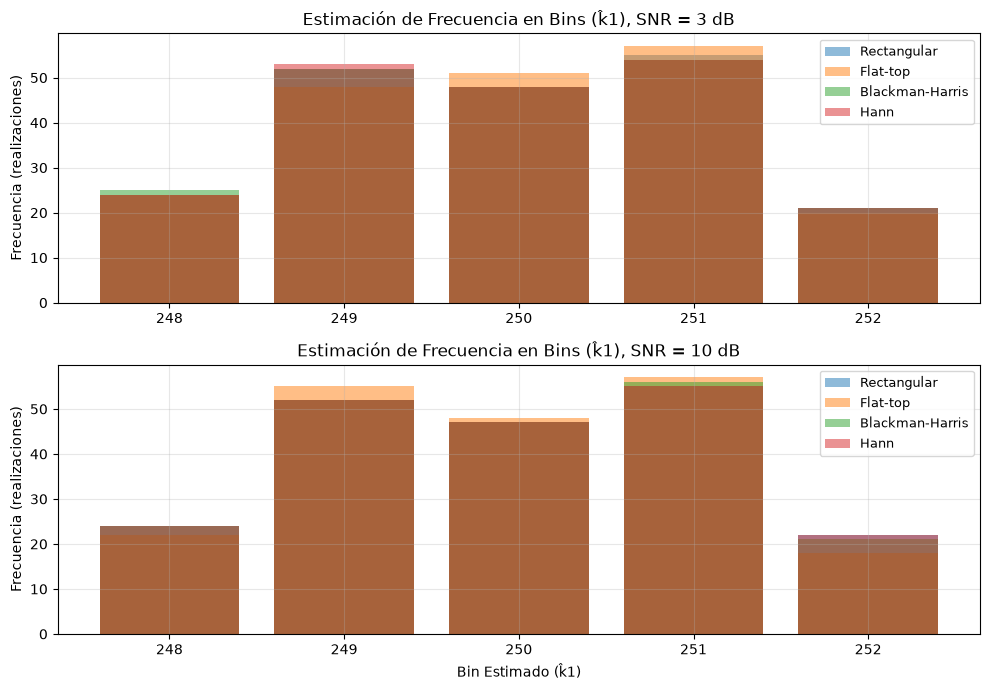

In [20]:

#%%                         HISTOGRAMA DE FRECUENCIA
bins_frec = np.arange(247.5, 253.5, 1)

plt.figure(figsize=(10, 7))

plt.subplot(2, 1, 1)
plt.hist(est_frec_v3, bins=bins_frec, alpha=0.5, label='Rectangular', rwidth=0.8)
plt.hist(est_frec_ft3, bins=bins_frec, alpha=0.5, label='Flat-top', rwidth=0.8)
plt.hist(est_frec_bh3, bins=bins_frec, alpha=0.5, label='Blackman-Harris', rwidth=0.8)
plt.hist(est_frec_h3, bins=bins_frec, alpha=0.5, label='Hann', rwidth=0.8)
plt.title('Estimación de Frecuencia en Bins (k̂1), SNR = 3 dB')
plt.ylabel('Frecuencia (realizaciones)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)

plt.subplot(2, 1, 2)
plt.hist(est_frec_v10, bins=bins_frec, alpha=0.5, label='Rectangular', rwidth=0.8)
plt.hist(est_frec_ft10, bins=bins_frec, alpha=0.5, label='Flat-top', rwidth=0.8)
plt.hist(est_frec_bh10, bins=bins_frec, alpha=0.5, label='Blackman-Harris', rwidth=0.8)
plt.hist(est_frec_h10, bins=bins_frec, alpha=0.5, label='Hann', rwidth=0.8)
plt.title('Estimación de Frecuencia en Bins (k̂1), SNR = 10 dB')
plt.xlabel('Bin Estimado (k̂1)')
plt.ylabel('Frecuencia (realizaciones)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()





Para el caso del histograma de la estimación de frecuencia, se puede notar que todas las ventanas presentan prácticamente el mismo comportamiento visual. Esto se debe a que el estimador utiliza la función argmax sobre el módulo de la FFT, la cual busca el índice de la posición máxima dentro de un vector discreto. Como los índices de un vector son por definición números enteros, argmax recorre las muestras frecuenciales de la DFT y devuelve la posición entera donde detecta el valor más alto, sin capacidad de devolver un valor decimal. De esta manera, la frecuencia continua real de la senoidal (que varía aleatoriamente en el rango de -2 a +2 bins respecto a la frecuencia central) queda simplemente acotada y redondeada al bin entero más cercano.

Esta característica de invariancia frente a la ventana elegida resulta ventajosa, ya que le otorga mayor robustez al estimador: la ubicación del bin de frecuencia no cambia según el tipo de ventana seleccionado. Esto es muy valioso en aplicaciones reales donde no siempre se conocen con precisión las características de la señal a medir.

La diferencia fundamental entre ambos estimadores radica en la naturaleza de lo que miden. El estimador de frecuencia busca la posición del pico en la grilla discreta de la DFT mediante argmax, lo cual resulta sumamente estable frente al tipo de ventana. Por el contrario, el estimador de amplitud mide la altura máxima del espectro, la cual varía drásticamente según cómo la curva de la ventana atenúa los bordes de la señal en el tiempo (generando distintos niveles de pérdida por acanalado o scalloping loss).

Analisis de zero padding en el estimador de frecuencia
Tal como se analizó en la tarea semanal previa, la aplicación de zero-padding consiste en rellenar con ceros el vector temporal para aumentar la longitud total de la DFT (de N a N\_pad). Este procedimiento no agrega información nueva ni mejora la resolución espectral física (la capacidad de separar dos frecuencias cercanas sigue dependiendo exclusivamente de la cantidad N de muestras reales recogidas). Sin embargo, produce una interpolación del espectro en el dominio de la frecuencia, evaluando la DTFT sobre una grilla de muestreo discreta mucho más densa.

Al reducirse el paso entre frecuencias de muestreo (Δf' = fs / N\_pad), se generan bins intermedios con precisión decimal en la grilla original (por ejemplo, evaluando puntos intermedios entre los bins 250 y 251). De esta manera, al aplicar la función argmax sobre la FFT con zero-padding, el estimador puede identificar la posición del valor máximo con mayor resolución, reduciendo drásticamente el error por discretización en la estimación de la frecuencia.

Asimismo, la aplicación de zero-padding beneficia de forma directa al estimador de amplitud. Al evaluar la DFT sobre una grilla frecuencial más densa, se incrementa la densidad de muestreo de la transformada de Fourier continua (DTFT). Esto permite que la muestra de valor máximo detectada por el estimador se encuentre mucho más cercana a la cima real del lóbulo principal de la ventana, reduciendo significativamente la pérdida por acanalado (scalloping loss) y permitiendo recuperar con mayor exactitud el valor pico de la señal continua.

## Conclusion

En este trabajo práctico se evaluó estadísticamente el desempeño de los estimadores de amplitud ($\hat{a}_1 = \max|X|$) y frecuencia discreta ($\hat{k}_1 = \arg\max|X|$) mediante simulaciones Monte Carlo sobre una señal senoidal desintonizada y contaminada con ruido blanco Gaussiano. A partir de los resultados obtenidos para $200$ realizaciones a niveles de $\text{SNR} = 3\text{ dB}$ y $10\text{ dB}$, se destacan las siguientes conclusiones principales: 
Compromiso en la estimación de amplitud: La ventana Flat-top demostró ser la alternativa superior para estimar el valor pico de la señal. Al poseer un lóbulo principal de cima plana, reduce de forma drástica la pérdida por acanalado (scalloping loss) cuando la frecuencia cae fuera del centro del bin, alcanzando el menor sesgo ($\approx -0.11$) y una varianza un orden de magnitud inferior ($\approx 0.02$) respecto a las demás ventanas ($\approx 0.12 - 0.22$). Dado que el sesgo en amplitud es un error determinístico que puede corregirse mediante calibración, la minimización de la varianza aleatoria convierte a la Flat-top en la opción más precisa e impredeciblemente estable.
Independencia del sesgo de amplitud respecto a la SNR: El sesgo en la estimación de amplitud se mantuvo prácticamente inalterado al cambiar el nivel de ruido de $3\text{ dB}$ a $10\text{ dB}$. Esto confirma que la pérdida de amplitud es un fenómeno puramente geométrico determinado por la atenuación de la ventana y el desfasaje de la frecuencia respecto a los bins discretos de la DFT, y no por la potencia del ruido aditivo. El nivel de SNR incide únicamente en la fluctuación aleatoria alrededor de la media (varianza).
Robustez y varianza en la estimación de frecuencia: Para el estimador de frecuencia discreta, el sesgo resultó prácticamente nulo ($\approx 0$) en todas las ventanas gracias a la simetría de la desintonía aleatoria $U(-2, 2)$ alrededor de la frecuencia nominal. El hecho de que los histogramas de frecuencia presenten un comportamiento visual casi idéntico evidencia la robustez del estimador frente a la elección de la ventana, ya que el operador argmax está acotado por la resolución discreta de la grilla de la DFT ($\Delta f = f_s/N$). No obstante, en la varianza numérica se aprecia que las ventanas con lóbulo principal puntiagudo (Rectangular, Hann y Blackman-Harris) ofrecen una menor dispersión ($\approx 0.081$) frente a la Flat-top ($\approx 0.126 - 0.171$), cuyo lóbulo anco favorece que el ruido mueva la ubicación del pico máximo entre bins adyacentes.
Efecto de la técnica de Zero-Padding: La aplicación de zero-padding demostró ser una herramienta eficaz para mejorar la precisión de ambos estimadores. Al densificar la grilla espectral, reduce el error por discretización  en la estimación de frecuencia y disminuye la pérdida por acanalado en la estimación de amplitud, al acercar las muestras discretas al pico real del lóbulo principal. Cabe destacar que esta mejora responde a una interpolación espectral en frecuencia y no a un incremento en la resolución espectral física del sistema, la cual sigue limitada por la cantidad de muestras reales N recopiladas en el tiempo.